
🔹 First 5 Rows:
                                         BROKERTITLE                TYPE  \
0        Brokered by Douglas Elliman  -111 Fifth Ave      Condo for sale   
1                                Brokered by Serhant      Condo for sale   
2                             Brokered by Sowae Corp      House for sale   
3                                Brokered by COMPASS      Condo for sale   
4  Brokered by Sotheby's International Realty - E...  Townhouse for sale   

       PRICE  BEDS       BATH  PROPERTYSQFT  \
0     315000     2   2.000000        1400.0   
1  195000000     7  10.000000       17545.0   
2     260000     4   2.000000        2015.0   
3      69000     3   1.000000         445.0   
4   55000000     7   2.373861       14175.0   

                                             ADDRESS                    STATE  \
0                               2 E 55th St Unit 803       New York, NY 10022   
1  Central Park Tower Penthouse-217 W 57th New Yo...       New York, NY 10019   


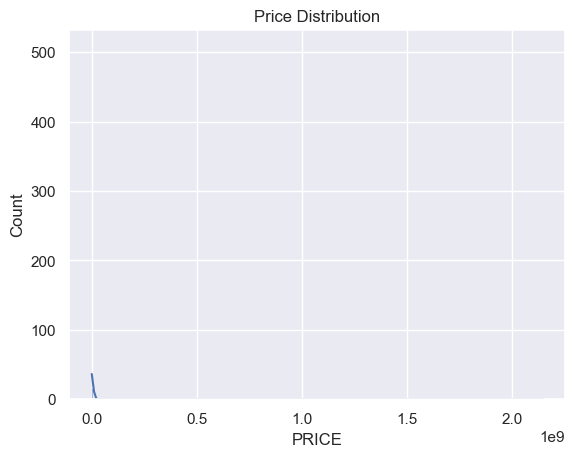

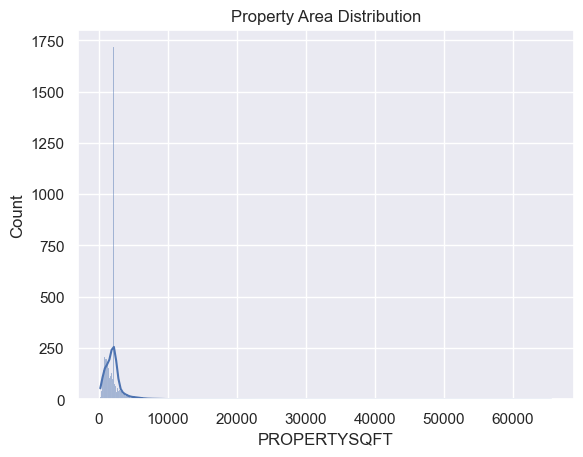

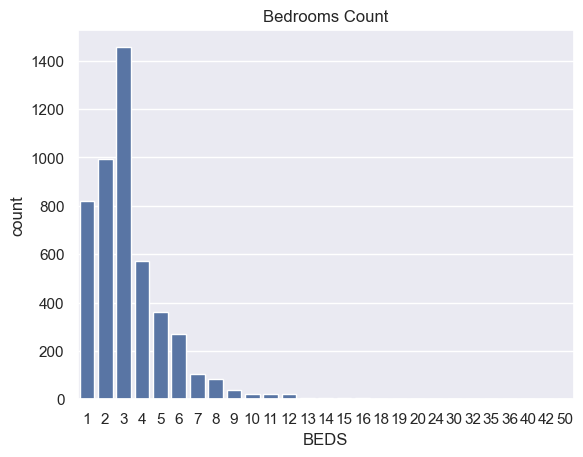


🔹 Skewness:
PRICE           66.800005
PROPERTYSQFT    12.800329
dtype: float64

🔹 Kurtosis:
PRICE           4566.855239
PROPERTYSQFT     258.555514
dtype: float64


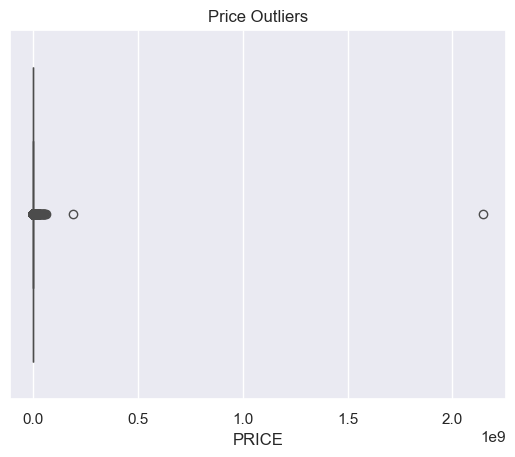


🔹 Number of Outliers in PRICE: 559


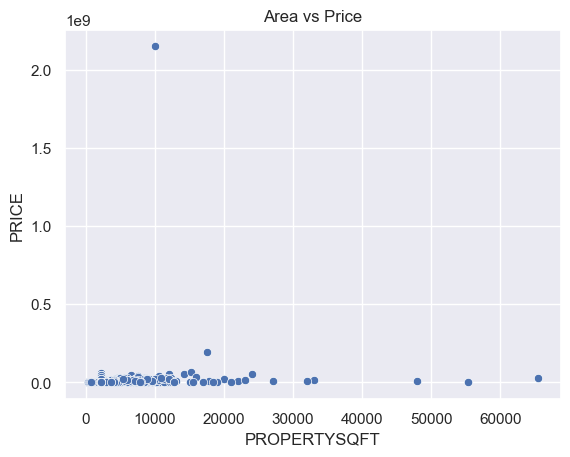

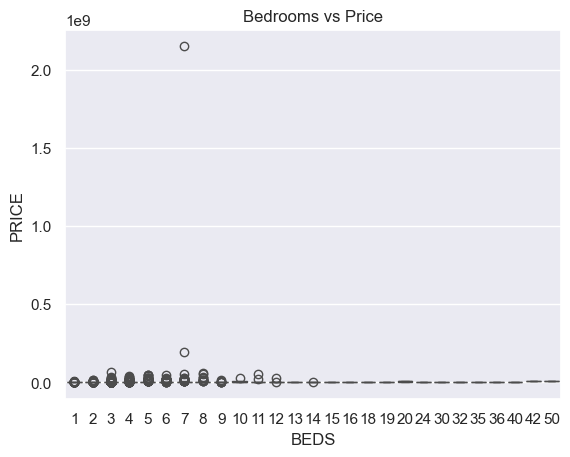

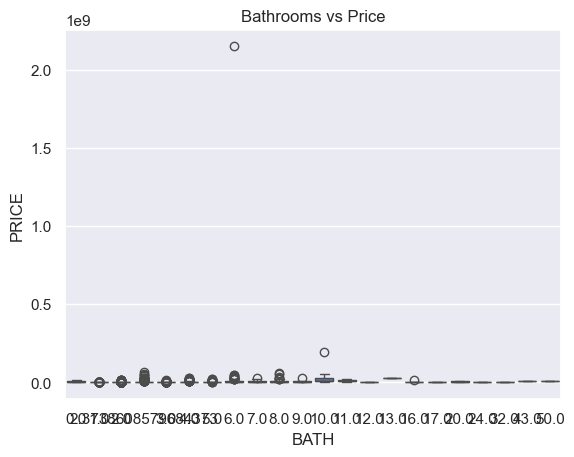

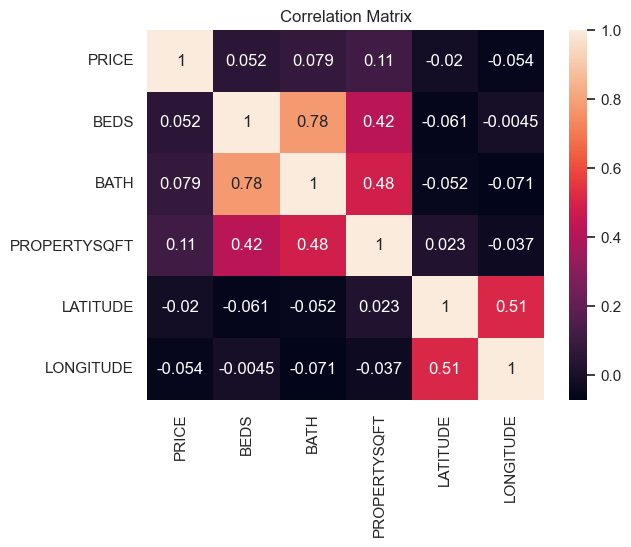

In [ ]:
# ============================================
# 📌 NY HOUSE DATASET - EDA PROJECT
# ============================================

# 🔷 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# 🔷 2. Load Dataset
df = pd.read_csv("NY-House-Dataset.csv")

# ============================================
# 🔥 BASIC UNDERSTANDING (PDF REQUIREMENT)
# ============================================

print("\n🔹 First 5 Rows:")
print(df.head())

print("\n🔹 Shape of Dataset:")
print(df.shape)

print("\n🔹 Info:")
print(df.info())

print("\n🔹 Statistical Summary:")
print(df.describe())

print("\n🔹 Missing Values:")
print(df.isnull().sum())

print("\n🔹 Unique Values:")
print(df.nunique())

# ============================================
# 🔥 UNIVARIATE ANALYSIS
# ============================================

# Price Distribution
plt.figure()
sns.histplot(df["PRICE"], kde=True)
plt.title("Price Distribution")
plt.show()

# Area Distribution
plt.figure()
sns.histplot(df["PROPERTYSQFT"], kde=True)
plt.title("Property Area Distribution")
plt.show()

# Bedrooms Count
plt.figure()
sns.countplot(x="BEDS", data=df)
plt.title("Bedrooms Count")
plt.show()

# ============================================
# 🔥 SKEWNESS & KURTOSIS (PDF CONCEPT)
# ============================================

print("\n🔹 Skewness:")
print(df[["PRICE", "PROPERTYSQFT"]].skew())

print("\n🔹 Kurtosis:")
print(df[["PRICE", "PROPERTYSQFT"]].kurt())

# ============================================
# 🔥 OUTLIERS DETECTION
# ============================================

# Boxplot for Price
plt.figure()
sns.boxplot(x=df["PRICE"])
plt.title("Price Outliers")
plt.show()

# IQR Method
Q1 = df["PRICE"].quantile(0.25)
Q3 = df["PRICE"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["PRICE"] < Q1 - 1.5*IQR) | (df["PRICE"] > Q3 + 1.5*IQR)]

print("\n🔹 Number of Outliers in PRICE:", len(outliers))

# ============================================
# 🔥 BIVARIATE ANALYSIS
# ============================================

# Price vs Area
plt.figure()
sns.scatterplot(x="PROPERTYSQFT", y="PRICE", data=df)
plt.title("Area vs Price")
plt.show()

# Price vs Bedrooms
plt.figure()
sns.boxplot(x="BEDS", y="PRICE", data=df)
plt.title("Bedrooms vs Price")
plt.show()

# Price vs Bathrooms
plt.figure()
sns.boxplot(x="BATH", y="PRICE", data=df)
plt.title("Bathrooms vs Price")
plt.show()

# ============================================
# 🔥 MULTIVARIATE ANALYSIS
# ============================================

# Correlation Heatmap
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Matrix")
plt.show()

# Pairplot
sns.pairplot(df)

# ============================================
# 🔥 FEATURE ENGINEERING (BONUS)
# ============================================

# Price per sqft
df["Price_per_sqft"] = df["PRICE"] / df["PROPERTYSQFT"]

plt.figure()
sns.histplot(df["Price_per_sqft"], kde=True)
plt.title("Price per Sqft Distribution")
plt.show()

# ============================================
# 🔥 INSIGHTS (IMPORTANT FOR ASSIGNMENT)
# ============================================

print("\n🔹 Key Insights:")

print("- Price distribution skewed hai (luxury properties ki wajah se)")
print("- Area aur price ka strong positive relation hai")
print("- Zyada bedrooms/bathrooms → high price")
print("- Outliers exist karte hain (very expensive houses)")
print("- Price per sqft better metric hai comparison ke liye")

